In [1]:
import numpy as np
import scipy.linalg as spl
from dataclasses import replace
from pulser.devices import Device, VirtualDevice, AnalogDevice, MockDevice
from pulser.waveforms import InterpolatedWaveform, ConstantWaveform, RampWaveform, BlackmanWaveform,CompositeWaveform
from pulser.channels import Rydberg, Raman, Microwave
from pulser import Pulse, Sequence, Register
from qutip import *
from pulser_simulation import QutipEmulator
import networkx as nx
from networkx import cut_size
from matplotlib import colormaps as cmaps
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def distance(p1, p2):
    return np.sqrt((p2[0] - p1[0]) ** 2 + (p2[1] - p1[1]) ** 2)

def cut_size_from_bitstring(bitstring, graph):
    S = []
    for node in graph.nodes():
        ind = int(node[1:])
        if bitstring[ind] == '1':
            S.append(node)
            
    return cut_size(graph, S, weight='weight')


def plot_graph_solution(G,sols):
    for i,s in enumerate(sols):
        colors=[]
        for node, b in enumerate(s):
            colors.append("crimson") if int(b) == 0 else colors.append("navy")
        nx.draw_networkx(G, node_color=colors, with_labels=True)
        plt.show()


def plot_graph_QPU_solution(G,count_dict,Nsol):
    sols=[x[0] for x in count_dict.most_common(Nsol)]
    for i,x in enumerate(sols):
        colors=[]
        for node, b in enumerate(x):
            colors.append("crimson") if int(b) == 0 else colors.append("navy")
        nx.draw_networkx(G, node_color=colors, with_labels=True,font_color='white')
        plt.show()
    
def plot_histogram_solution(gs_states,C,Nsol):
    C = dict(sorted(C.items(), key=lambda item: item[1], reverse=True)[:Nsol])
    indexes = gs_states  # QUBO solutions
    color_dict = {key: "r" if key in indexes else "g" for key in C}
    plt.figure(figsize=(7, 4))
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.bar(C.keys(), C.values(), width=0.5, color=color_dict.values())
    plt.xticks(rotation="vertical")
    plt.show()


## Definition of the device

In [2]:
from pulser import Pulse, Register, Sequence
from pulser.devices._device_datacls import BaseDevice
from pulser_simulation import SimConfig
from pulser.channels.dmm import DMM
from pulser.channels import Rydberg
from pulser.devices import Device
from numpy import pi

#make the device:
dmm = DMM(
    clock_period=4,
    min_duration=16,
    max_duration=2**26,
    mod_bandwidth=8,
    bottom_detuning = -2 * pi * 20, # detuning between 0 and -20 MHz
    total_bottom_detuning= -2 * pi * 2000,  # total detuning
)

global_channel = Rydberg.Global(
            max_abs_detuning= 10 * 2 * pi,
            max_amp= 2 * 2 * pi,  
            clock_period=4,
            min_duration=16,
            mod_bandwidth=10,  
        )

dmm_device = Device(
    name=f"dmm-device",
    dimensions=2,
    rydberg_level=60, 
    min_atom_distance=5,
    max_atom_num=100, 
    max_radial_distance=100,
    channel_objects= [global_channel],
    pre_calibrated_layouts=(),  # add Square and Triangular?
    dmm_objects = [dmm]
)

noise_config = SimConfig(
                runs=50,
                samples_per_run= 10,
                noise=("SPAM", "doppler"),
                eta = 0.005,
                epsilon = 0.03,
                epsilon_prime= 0.08,
                temperature=30,
                laser_waist=148,
            )





## Register
Let us now define a register assuming to fix the position of the atoms. 
The maximum $\Omega$ you can use effectively is given by the blockade radius you want to achieve. The Rydberg blockade radius changes during the evolution if we change $\Omega$. What is actually important is that the minimum blockade radius is never below a threshold if we want to be sure that a given condition is satisfied.


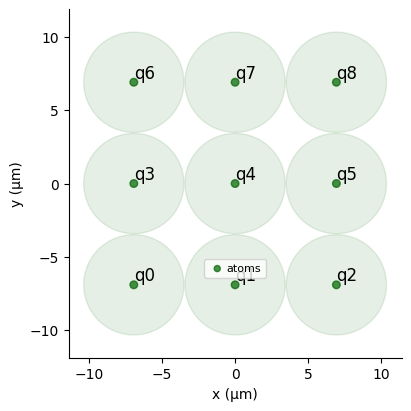

/tmp/ipykernel_712044/3976737201.py:26: RuntimeWarning: divide by zero encountered in divide
  int_matrix=device.interaction_coeff/(dist_matrix**6)


In [3]:
from pulser.register.special_layouts import (
    SquareLatticeLayout,
    TriangularLatticeLayout,
)

default_device = dmm_device
default_omega_max = default_device.channels["rydberg_global"].max_amp
default_detuning_max = default_device.channels['rydberg_global'].max_abs_detuning
default_noise = noise_config
detuning_max = np.min([4*default_omega_max, default_detuning_max])
device=dmm_device
### Register Layout
max_U_trig = detuning_max/6
R_b=device.rydberg_blockade_radius(max_U_trig)
safe_spacing=5
a=1.01*R_b
if a <5:
    print('lattice spacing not allowed')
reg_layout = SquareLatticeLayout(10, 10, a )
Register=reg_layout.square_register(side=3)
Register.draw(blockade_radius=R_b,
    draw_half_radius=True)

coords = {k: v.tolist() for k, v in Register.qubits.items()}
dist_matrix=np.array([[distance(coords['q'+str(i)],coords['q'+str(j)]) for i in range(len(coords))] for j in range(len(coords))])
int_matrix=device.interaction_coeff/(dist_matrix**6)
np.fill_diagonal(int_matrix,0)

### Graph

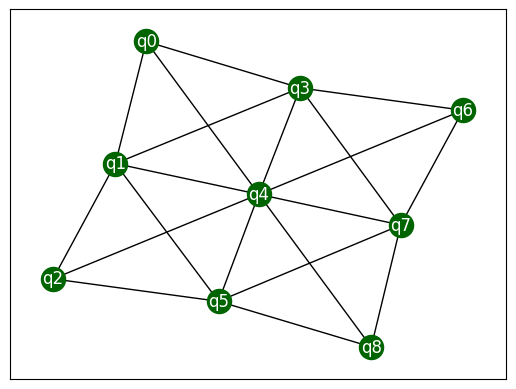

In [4]:
nnodes=len(Register.qubits.items())
coords = {k: v.tolist() for k, v in Register.qubits.items()}
#define the graph
#note - you could define weights here.
G = nx.Graph()
for i in range(nnodes):
    G.add_node('q{}'.format(i))
for i in range(nnodes-1):
    for j in range(i+1,nnodes):
        ri = coords['q{}'.format(i)]
        rj = coords['q{}'.format(j)]
        if distance(ri,rj) <= 1.02*np.sqrt(2)*a:
            G.add_edge('q{}'.format(i), 'q{}'.format(j), weight = 1.0)
nx.draw_networkx(G, with_labels=True,node_color='darkgreen',font_color='white')

## Possible solutions

9
Solutions ['000111000', '010010010', '101101101', '111000111']
Maximum number of cuts:  [14.0, 14.0, 14.0, 14.0]


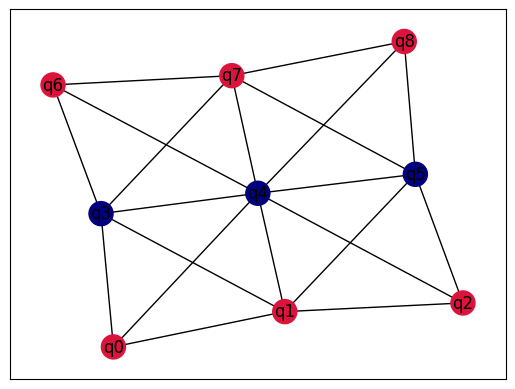

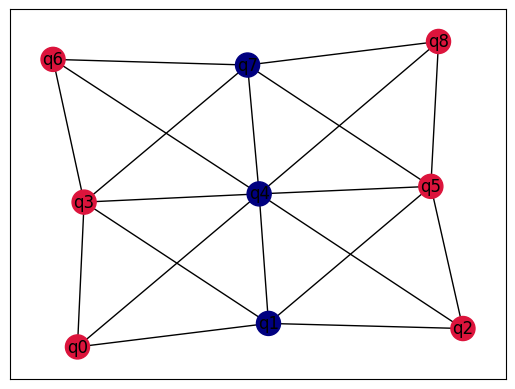

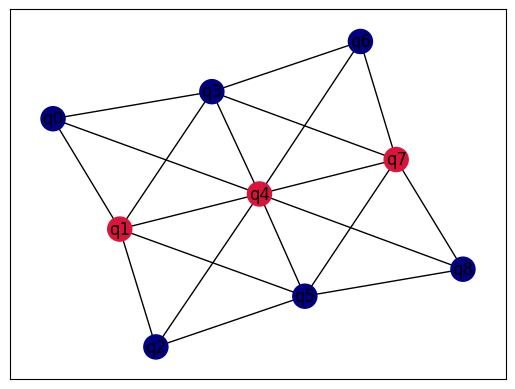

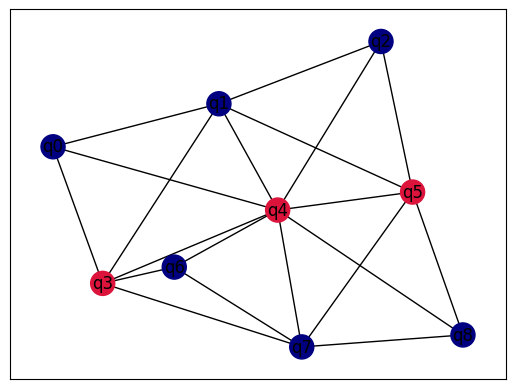

In [5]:
J=nx.adjacency_matrix(G).toarray()

ZZ_ops=[]
L=J.shape[0]
print(L)
for i in range(L):
    for j in range(i+1,L):
        if J[i,j]==1:
            ZZ_ops.append(tensor([qeye(2)]*i+[J[i,j]*sigmaz()]+[qeye(2)]*(j-i-1)+[sigmaz()]+[qeye(2)]*(L-1-j)))

costst=np.zeros(2**L)
for i in range(2**L):
    V=Qobj(basis(2**L,i),dims=[[2 for _ in range(L)],[1 for _ in range(L)]])
    costst[i]=sum([0.5*(1-V.dag()*op*V).tr() for op in ZZ_ops])
idx=np.argwhere(costst==max(costst))[:]
sols=[bin(x[0])[2:].zfill(L) for x in idx]
costs=[x[0] for x in costst[idx]]
print('Solutions',sols)
print('Maximum number of cuts: ',costs)
plot_graph_solution(G,sols)

## Here I define the detuing weights according to the QUBO I have to solve

In [6]:
laplacian = nx.laplacian_matrix(G)
mat_Q = laplacian.toarray()
off_diag_Q = -1*np.array(np.copy(mat_Q))
off_diag_Q=off_diag_Q*int_matrix
np.fill_diagonal(off_diag_Q, 0.0)

diag_Q=np.array([sum(off_diag_Q[i,:]) for i in range(len(off_diag_Q))])

delta_0 = -max(diag_Q)
delta_f = max(diag_Q)
Omega= max(off_diag_Q.flatten())
#define dmm_ weights l'idea è che sottraggo allo sweep solito del QAOA un detuning che mi serve in modo tale che i pesi
#sulla diagonale siano quelli che mi servano per fare encoding del problema (?)
weights_x0 = 1 - diag_Q/np.max(diag_Q)

detuning_weights = weights_x0
final_dmm = -delta_f
print(final_dmm)
#####

mat_Q=off_diag_Q
np.fill_diagonal(mat_Q,diag_Q)

mat_QUBO=laplacian.toarray()

-35.514283145168385


### Implementing QA with DMM

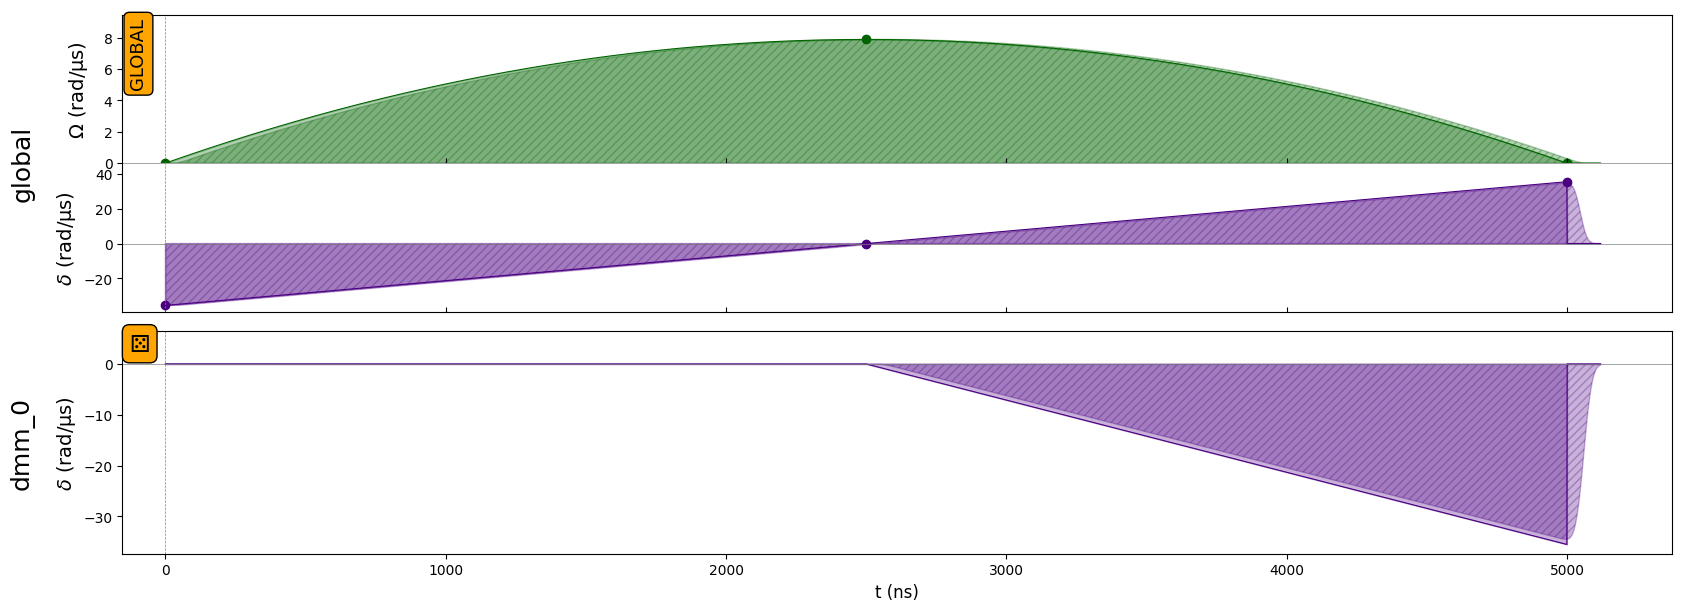

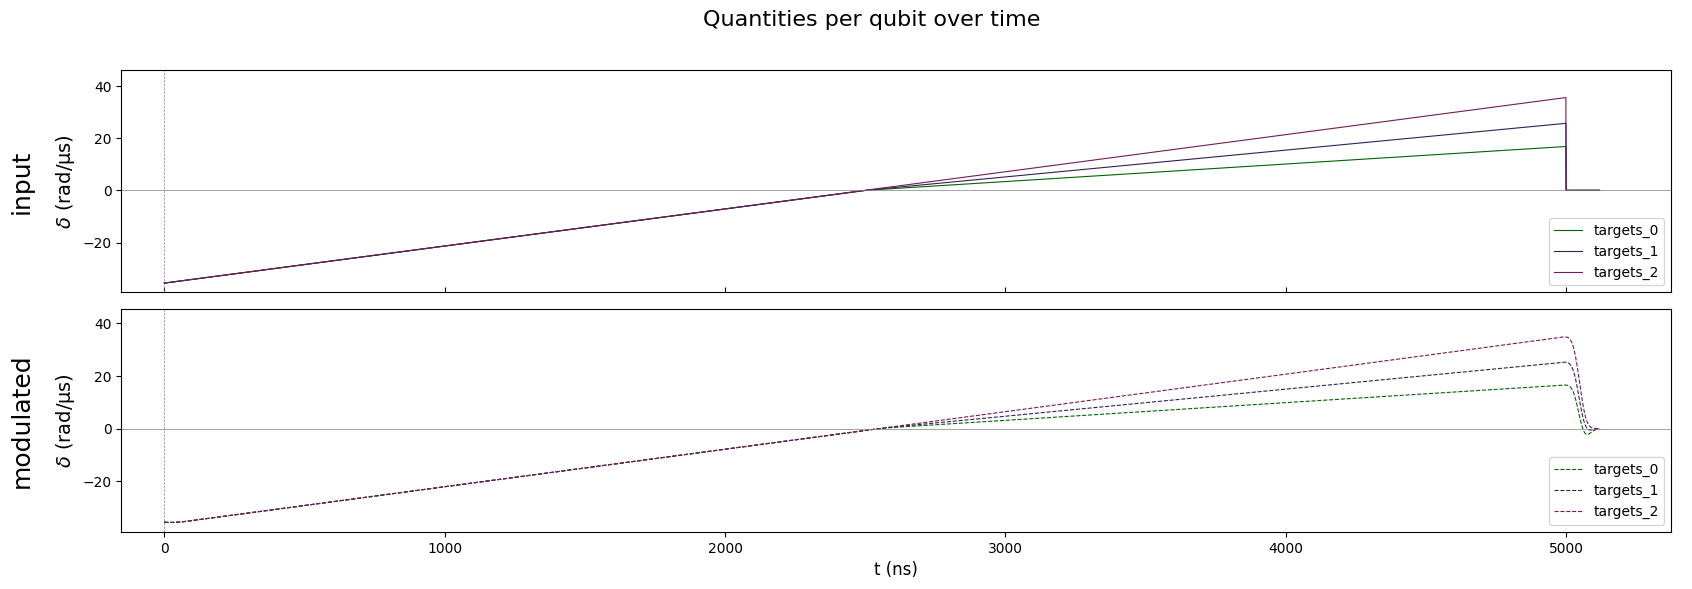

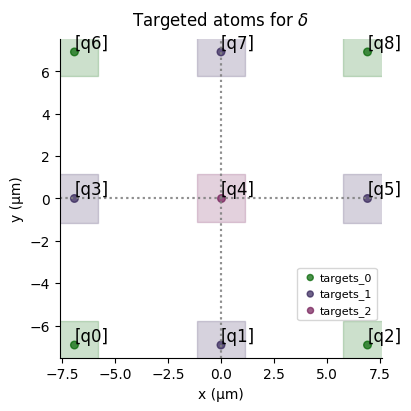

10.0%. Run time:   0.18s. Est. time left: 00:00:00:01
20.0%. Run time:   0.32s. Est. time left: 00:00:00:01
30.0%. Run time:   0.48s. Est. time left: 00:00:00:01
40.0%. Run time:   0.68s. Est. time left: 00:00:00:01
50.0%. Run time:   0.91s. Est. time left: 00:00:00:00
60.0%. Run time:   1.18s. Est. time left: 00:00:00:00
70.0%. Run time:   1.47s. Est. time left: 00:00:00:00
80.0%. Run time:   1.77s. Est. time left: 00:00:00:00
90.0%. Run time:   2.09s. Est. time left: 00:00:00:00
Total run time:   2.42s


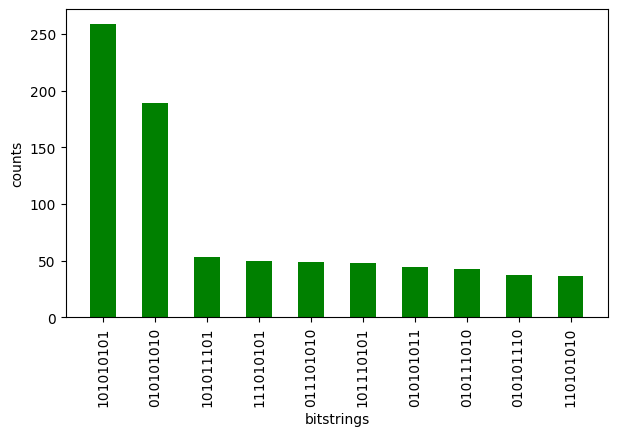

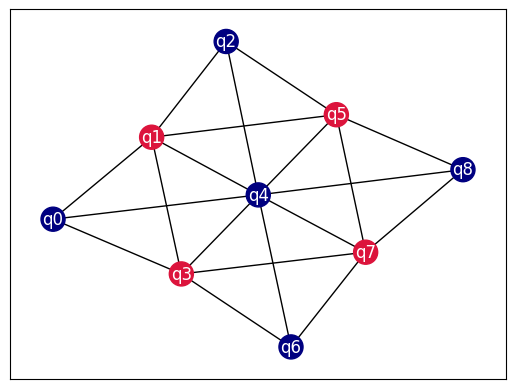

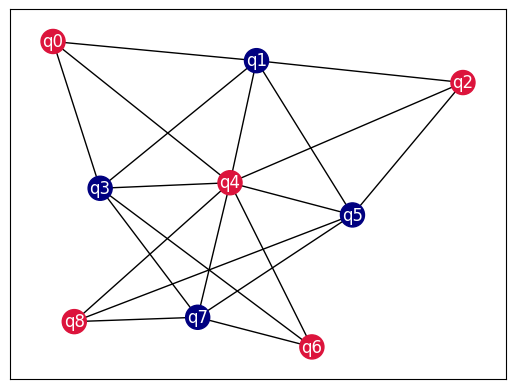

In [8]:
seq = Sequence(Register, dmm_device)
T=5000

adiabatic_pulse = Pulse(
    InterpolatedWaveform(T, [0, Omega, 0]),
    InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)

seq.declare_channel("global","rydberg_global")
seq.add(adiabatic_pulse,"global")

detuning_weights_dict = dict(zip(Register.qubit_ids, detuning_weights))
detuning_map = Register.define_detuning_map(detuning_weights_dict, "dmm_0")
seq.config_detuning_map(detuning_map, "dmm_0")
wf0 = RampWaveform(T/2, 0,0)
seq.add_dmm_detuning(wf0, "dmm_0")
wf0 = RampWaveform(T/2, 0,delta_0)
seq.add_dmm_detuning(wf0, "dmm_0")

seq.draw(draw_qubit_det=True)      


simul = QutipEmulator.from_sequence(seq)
results = simul.run(progress_bar=True)
final = results.get_final_state()
count_dict = results.sample_final_state(N_samples=1000)

plot_histogram_solution(sols,count_dict,Nsol=10)
plot_graph_QPU_solution(G,count_dict,Nsol=2)

# Implementing QA without DMM

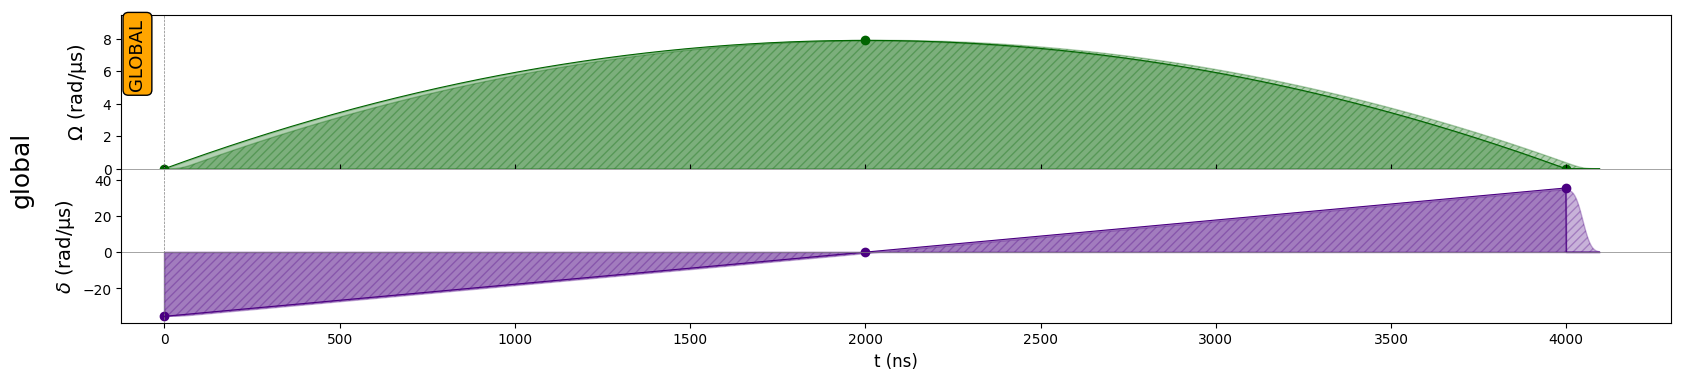

10.0%. Run time:   0.13s. Est. time left: 00:00:00:01
20.0%. Run time:   0.23s. Est. time left: 00:00:00:00
30.0%. Run time:   0.36s. Est. time left: 00:00:00:00
40.0%. Run time:   0.50s. Est. time left: 00:00:00:00
50.0%. Run time:   0.66s. Est. time left: 00:00:00:00
60.0%. Run time:   0.85s. Est. time left: 00:00:00:00
70.0%. Run time:   1.06s. Est. time left: 00:00:00:00
80.0%. Run time:   1.30s. Est. time left: 00:00:00:00
90.0%. Run time:   1.53s. Est. time left: 00:00:00:00
Total run time:   1.79s


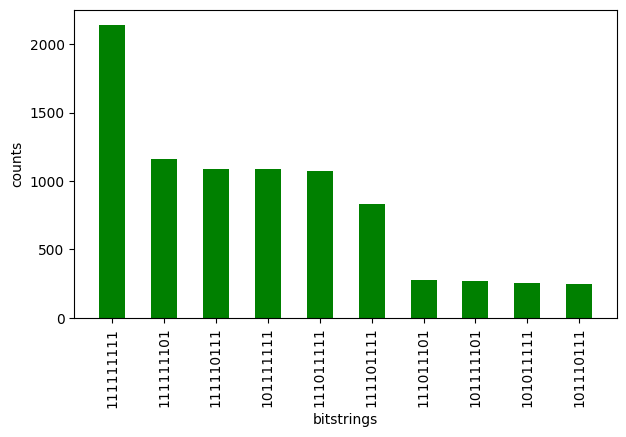

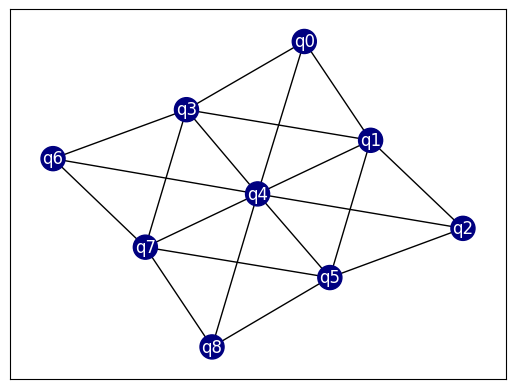

In [9]:
seq = Sequence(Register, dmm_device)
J0=int_matrix[0,1]
T=4000

adiabatic_pulse = Pulse(
    InterpolatedWaveform(T, [0, Omega, 0]),
    InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)

seq.declare_channel("global","rydberg_global")
seq.add(adiabatic_pulse,"global")
seq.draw()      


simul = QutipEmulator.from_sequence(seq)
results = simul.run(progress_bar=True)
final = results.get_final_state()
count_dict = results.sample_final_state(N_samples=10000)

plot_histogram_solution(sols,count_dict,Nsol=10)
plot_graph_QPU_solution(G,count_dict,Nsol=1)